# 01 - Data and knowledge base

**Questions this notebook answers:** what data does the assistant use, why, what can it therefore answer, and how is it cleaned?

```
01 Data + knowledge base  ->  02 Build index  ->  03 RAG pipeline  ->  04 Evaluation
        (you are here)
```

A RAG system can only be as good as the documents it retrieves from, so the knowledge base is chosen to match the questions the assistant is meant to answer, not to be as large as possible.
The notebooks are shipped without outputs. Run them top to bottom to see the numbers.

## Scope

The assistant is an **educational health-information assistant**. It is not an AI doctor.

| | |
|---|---|
| **In scope** | Diseases and conditions: what they are, symptoms, causes and risk factors, prevention, tests and diagnosis, and how they are treated in general |
| **Partly in scope** | Medicines, but only as far as the sources describe them (for example the kinds of medicine used for a condition). See "The medication gap" below. |
| **Out of scope** | Diagnosing the user, personal advice, doses, whether to start, stop or combine medicines, interpreting someone's test results, live or current information |

## Sources

| Source | What it is | Why it is in |
|---|---|---|
| **MedQuAD** (`lavita/MedQuAD`) | Question/answer pairs written by NIH websites (NIDDK, CDC, NHLBI, NINDS, Cancer.gov, ...) | Written for the public and organised by question type (symptoms, causes, treatment, prevention, tests...). This copy keeps each document's URL and publisher, which the citations need. |
| **MedlinePlus** (NLM health-topic XML) | One plain-language summary per health topic | Official, with stable URLs that are easy to cite. |

Two things were considered and left out: **PubMedQA** (research abstracts with auto-generated questions; its artificial split alone has 211,269 rows, about twelve times the two sources above combined) and **MedRedQA** (informal Reddit replies about one person's situation). Both fit consumer questions poorly. They were left out on domain fit; their effect on retrieval was not measured.

## The medication gap

Medication is the one part of the intended scope these sources do not really cover:

* In `lavita/MedQuAD`, the answers of the GARD, A.D.A.M., herbs-and-supplements and **drug** subsets were removed for copyright (31,034 rows), and no drug-specific question type remains. The first table below shows this.
* MedlinePlus drug pages are AHFS Consumer Medication Information, copyrighted by ASHP, so they are not ingested.
* The open alternative is FDA drug labels (DailyMed / openFDA). They are written for clinicians, and adding them is a separate ingestion step that was not built here.

So medication is scoped to what the health-topic sources say, and the assistant must abstain when they say nothing. It must never fill the gap from the model's memory. Notebook 04 reports medication questions separately so the gap stays visible.

In [1]:
import io
import re
import sys
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from datasets import load_dataset

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import config
from src.kb import (
    BOILERPLATE, build_kb, clean_text, parse_medlineplus_xml, prepare_medlineplus, prepare_medquad,
)

RAW_DIR = ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)
config.KB_PATH.parent.mkdir(parents=True, exist_ok=True)

## 1. MedQuAD

Rows without answer text are dropped later. First, how many rows does each NIH publisher have, and how many have an answer?

In [2]:
dataset = load_dataset("lavita/MedQuAD")
raw_medquad = dataset[list(dataset.keys())[0]].to_pandas()
raw_medquad.to_csv(RAW_DIR / "medquad_raw.csv", index=False)

raw_medquad["has_answer"] = raw_medquad["answer"].fillna("").str.strip() != ""
by_publisher = raw_medquad.groupby("document_source").agg(rows=("has_answer", "size"), with_answer=("has_answer", "sum"))
print(by_publisher.sort_values("rows", ascending=False).to_string())
print(f"\ntotal: {len(raw_medquad):,} rows, {raw_medquad['has_answer'].sum():,} with an answer")

                        rows  with_answer
document_source                          
ADAM                   17348            0
MPlusDrugs             12889            0
GHR                     5430         5430
GARD                    5394         5389
NIDDK                   1192         1192
NINDS                   1088         1088
MPlusHealthTopics        981          981
MPlusHerbsSupplements    792            0
NIHSeniorHealth          769          769
CancerGov                729          729
NHLBI                    559          559
CDC                      270          270

total: 47,441 rows, 16,407 with an answer


The publishers with no answers are the ones removed for copyright (including the drug subset). The question types that do have answers:

In [3]:
raw_medquad.loc[raw_medquad["has_answer"], "question_type"].value_counts().to_frame("answered rows")

,answered rows
question_type,
information,4535
symptoms,2748
treatment,2442
inheritance,1446
frequency,1120
genetic changes,1087
causes,727
exams and tests,653
research,395


## 2. MedlinePlus

MedlinePlus publishes one zipped XML file with every health topic. The file name contains the date, so it is read from the download page.

In [4]:
page = requests.get("https://medlineplus.gov/xml.html", timeout=30).text
zip_url = re.findall(r"https://medlineplus\.gov/xml/mplus_topics_compressed_\d{4}-\d{2}-\d{2}\.zip", page)[0]
print(zip_url)

archive = zipfile.ZipFile(io.BytesIO(requests.get(zip_url, timeout=120).content))
xml_name = [name for name in archive.namelist() if name.endswith(".xml")][0]

raw_medline = parse_medlineplus_xml(archive.read(xml_name))
raw_medline.to_csv(RAW_DIR / "medlineplus_raw.csv", index=False)
print(f"English health topics: {len(raw_medline):,}")

https://medlineplus.gov/xml/mplus_topics_compressed_2026-10-07.zip
English health topics: 1,017


## 3. Clean

Each step is in `src/kb.py` and has a reason:

* **Drop rows without an answer**, broken questions such as `What is (are) ?` (empty topic name), and duplicates (the longer answer is kept).
* **Remove HTML tags** with a pattern that matches real tags only, so clinical text like `<5 mg` survives. MedlinePlus summaries are real HTML, so they go through BeautifulSoup.
* **Cut NIH site text** (`Top of Page`, `Related Pages`, ...) from the end of MedQuAD answers. It is navigation, not content, and would otherwise be retrieved and quoted.
* **Keep provenance.** Every document keeps a source name, a title and a URL. These become the citations users see.

In [5]:
medquad = prepare_medquad(raw_medquad)
medline = prepare_medlineplus(raw_medline)
print(f"MedQuAD:     {raw_medquad['has_answer'].sum():>6,} with an answer -> {len(medquad):>6,} documents")
print(f"MedlinePlus: {len(raw_medline):>6,} topics -> {len(medline):>6,} documents")

# one example whose document survived, before and after cleaning
pattern = "|".join(re.escape(marker) for marker in BOILERPLATE)
raw_questions = raw_medquad["question"].apply(clean_text)
survived = raw_medquad["answer"].fillna("").str.contains(pattern) & raw_questions.isin(medquad["question"])
if survived.any():
    example = raw_medquad[survived].iloc[0]
    cleaned = medquad.loc[medquad["question"] == clean_text(example["question"]), "text"].iloc[0]
    print("\nraw answer, last 200 characters:\n ...", str(example["answer"])[-200:])
    print("\ncleaned answer, last 200 characters:\n ...", cleaned[-200:])

MedQuAD:     16,407 with an answer -> 14,978 documents
MedlinePlus:  1,017 topics ->  1,015 documents

raw answer, last 200 characters:
 ...  pharmacist. 
    
   
 
   
*Use of trade names is for identification purposes only and does not imply endorsement by the Public Health Service or by the U.S. Department of Health and Human Services.

cleaned answer, last 200 characters:
 ... by lice or nits that may have fallen off the head or crawled onto furniture or clothing. - Do not use fumigant sprays; they can be toxic if inhaled or absorbed through the skin. Prevent Reinfestation:


## 4. The knowledge base

One table, the same columns whatever the source: `doc_id, source, title, url, question, text`.
Answer length decides how many chunks a document becomes in notebook 02.

15,993 documents
             documents  median_words
source                              
MedQuAD          14978         141.0
MedlinePlus       1015         193.0
documents without a URL: 0


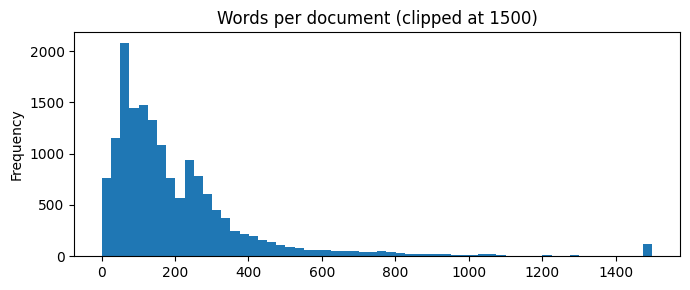

,doc_id,source,title,url,question,text,words
0,0,MedQuAD (CancerGov),Breast Cancer,https://www.cancer.gov/types/breast/patient/br...,What are the treatments for Breast Cancer?,Key Points - There are different types of trea...,4281
1,1,MedQuAD (CancerGov),Childhood Soft Tissue Sarcoma,https://www.cancer.gov/types/soft-tissue-sarco...,What are the treatments for Childhood Soft Tis...,Key Points - There are different types of trea...,3708
2,2,MedQuAD (CancerGov),Childhood Vascular Tumors,https://www.cancer.gov/types/soft-tissue-sarco...,What is (are) Childhood Vascular Tumors?,Key Points - Childhood vascular tumors form fr...,3692


In [6]:
kb = build_kb(medquad, medline)
kb["words"] = kb["text"].str.split().str.len()

print(f"{len(kb):,} documents")
print(kb.groupby(kb["source"].str.split(" ").str[0]).agg(documents=("doc_id", "size"), median_words=("words", "median")).to_string())
print(f"documents without a URL: {(kb['url'] == '').sum():,}")

kb["words"].clip(upper=1500).plot.hist(bins=60, figsize=(7, 3), title="Words per document (clipped at 1500)")
plt.tight_layout()
plt.show()
kb.head(3)

## 5. Does the knowledge base cover the scope? A check with the evaluation questions

The evaluation set has 20 `medication` questions, most of them about one named drug ("What are the side effects of metformin?").
For each drug name below, this counts documents that are *about* the drug (name in the title) and documents that only *mention* it.
A document that only mentions a drug while describing a condition's treatment cannot answer questions about its side effects or precautions.

In [7]:
eval_questions = pd.read_csv(config.EVAL_PATH)
print(eval_questions.loc[eval_questions["type"] == "medication", "question"].head(8).to_string(index=False))

drugs = ["metformin", "ibuprofen", "paracetamol", "acetaminophen", "amoxicillin", "omeprazole", "levothyroxine",
         "warfarin", "aspirin", "statin", "ACE inhibitor", "antihistamine", "corticosteroid", "insulin"]
titles, texts = kb["title"].str.lower(), kb["text"].str.lower()
pd.DataFrame({
    "documents about it (in title)": [int(titles.str.contains(d.lower(), regex=False).sum()) for d in drugs],
    "documents that mention it": [int(texts.str.contains(d.lower(), regex=False).sum()) for d in drugs],
}, index=drugs)

    What are the common side effects of metformin?
  Can I take ibuprofen and acetaminophen together?
                     What is paracetamol used for?
           What are the side effects of ibuprofen?
Is it safe to drink alcohol while taking metfor...
                              How do statins work?
             What are the side effects of statins?
                     What is amoxicillin used for?


,documents about it (in title),documents that mention it
metformin,0,14
ibuprofen,0,58
paracetamol,0,0
acetaminophen,0,30
amoxicillin,0,1
omeprazole,0,8
levothyroxine,0,2
warfarin,13,33
aspirin,0,142
statin,7,63


Read the table like this: many mentions but no documents about the drug means the assistant can say what a condition's treatment generally involves, but not what a particular drug does or what its side effects are.
That is the medication limit stated above. Everything else in the scope (conditions, symptoms, causes, prevention, tests, treatment overviews) is what both sources are made of, and notebook 04 checks it with the evaluation questions.

## 6. Checks and save

In [8]:
assert kb["doc_id"].is_unique
assert (kb["text"].str.len() > 0).all() and (kb["title"].str.len() > 0).all()

kb.drop(columns="words").to_csv(config.KB_PATH, index=False)
print(f"saved {len(kb):,} documents -> {config.KB_PATH.relative_to(ROOT)}")

saved 15,993 documents -> data\processed\kb_documents.csv


**Next:** `02_build_index.ipynb` splits these documents into chunks, embeds them and builds the search index.